In [1]:
from IPython.display import clear_output
!pip install pip3-autoremove
!pip-autoremove torch torchvision torchaudio -y
!pip install torch torchvision torchaudio xformers --index-url https://download.pytorch.org/whl/cu121
!pip install unsloth
# Also get the latest nightly Unsloth!
!pip uninstall unsloth -y && pip install --upgrade --no-cache-dir --no-deps git+https://github.com/unslothai/unsloth.git
!pip install --upgrade --no-cache-dir transformers
clear_output()

In [ ]:
import huggingface_hub

huggingface_hub.login(token="hf_XXXXXXXXXXXXXXXXXXXXX")

In [3]:
import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    BitsAndBytesConfig
)
from peft import PromptTuningConfig, get_peft_model, TaskType
from datasets import Dataset
import matplotlib.pyplot as plt
import json

In [4]:
def load_model(model_name="meta-llama/Llama-3.2-3B-Instruct"):
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.pad_token = tokenizer.eos_token  # Set padding token
    
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.float16
    )
    
    return model, tokenizer

In [5]:
def generate_response(model, tokenizer, prompt, max_length=200):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    ).to(model.device)
    
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_length,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.pad_token_id
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [6]:
def setup_prompt_tuning(model):
    peft_config = PromptTuningConfig(
        task_type=TaskType.CAUSAL_LM,
        num_virtual_tokens=20,
        prompt_tuning_init="TEXT",
        prompt_tuning_init_text="Answer the following question:",
        tokenizer_name_or_path="meta-llama/Llama-3.2-3B-Instruct",
    )
    return get_peft_model(model, peft_config)

In [32]:
def train_model(model, tokenizer, train_dataset, eval_dataset=None):
    def tokenize_function(examples):
        return tokenizer(
            examples["text"],
            truncation=True,
            max_length=512,
            padding="max_length",
            add_special_tokens=True
        )

    tokenized_train = train_dataset.map(tokenize_function, batched=True)
    
    if eval_dataset:
        tokenized_eval = eval_dataset.map(tokenize_function, batched=True)

    training_args = TrainingArguments(
        output_dir="./prompt_tuning_results",
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        num_train_epochs=5,
        learning_rate=3e-5,
        logging_steps=20,
        evaluation_strategy="steps" if eval_dataset else "no",
        eval_steps=20,
        save_strategy="no",
        optim="paged_adamw_32bit",
        gradient_accumulation_steps=2,
        fp16=True,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_eval if eval_dataset else None,
        data_collator=lambda data: {
            "input_ids": torch.stack([torch.tensor(d["input_ids"]) for d in data]),
            "attention_mask": torch.stack([torch.tensor(d["attention_mask"]) for d in data]),
            "labels": torch.stack([torch.tensor(d["input_ids"]) for d in data])
        }
    )

    trainer.train()
    return trainer

In [29]:
def plot_loss(trainer):
    history = trainer.state.log_history
    train_loss = [x['loss'] for x in history if 'loss' in x]
    eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_loss, label='Training Loss')
    if eval_loss:
        plt.plot(eval_loss, label='Validation Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training Progress')
    plt.legend()
    plt.show()

In [18]:
def read_dataset(ds_path):
    dataset = []
    empty_count = 0
    error_count = 0
    
    with open(ds_path, 'r') as f:
        for line_num, line in enumerate(f, 1):
            try:
                # Load conversation data
                conversation = json.loads(line)
                
                # Validate conversation format
                if not isinstance(conversation, list):
                    print(f"Skipping line {line_num}: Not a list format")
                    error_count += 1
                    continue
                    
                # Filter valid messages
                filtered = [
                    msg for msg in conversation 
                    if isinstance(msg, dict) and 
                    msg.get('role') in ['user', 'assistant'] and 
                    msg.get('content')
                ]
                
                # Skip empty conversations
                if not filtered:
                    empty_count += 1
                    continue
                
                # Format text using chat template
                formatted_text = tokenizer.apply_chat_template(
                    filtered,
                    tokenize=False,
                    add_generation_prompt=False
                )
                
                dataset.append({
                    "conversations": filtered,
                    "text": formatted_text
                })
                
            except json.JSONDecodeError:
                print(f"Skipping invalid JSON at line {line_num}")
                error_count += 1
            except Exception as e:
                print(f"Error processing line {line_num}: {str(e)}")
                error_count += 1

    print(f"Processed {len(dataset)} valid conversations")
    print(f"Skipped {empty_count} empty conversations")
    print(f"Encountered {error_count} errors")
    return dataset

In [10]:
model, tokenizer = load_model()

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

In [11]:
!wget https://huggingface.co/datasets/miladmim/slim-orca-dedup-chat-50k-persian/resolve/main/data.jsonl?download=true

--2025-02-02 11:33:27--  https://huggingface.co/datasets/miladmim/slim-orca-dedup-chat-50k-persian/resolve/main/data.jsonl?download=true
Resolving huggingface.co (huggingface.co)... 3.165.160.61, 3.165.160.12, 3.165.160.59, ...
Connecting to huggingface.co (huggingface.co)|3.165.160.61|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs-us-1.hf.co/repos/03/91/039119bf3b6f3c083e8207d297da2d654c372ba1b6778664345655e6e4af7aa5/3ca27a9b4e6f28661e2ac780ba648b1cf983c2e4508ceba00ab86dc3b2d465f3?response-content-disposition=attachment%3B+filename*%3DUTF-8%27%27data.jsonl%3B+filename%3D%22data.jsonl%22%3B&Expires=1738499607&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTczODQ5OTYwN319LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy11cy0xLmhmLmNvL3JlcG9zLzAzLzkxLzAzOTExOWJmM2I2ZjNjMDgzZTgyMDdkMjk3ZGEyZDY1NGMzNzJiYTFiNjc3ODY2NDM0NTY1NWU2ZTRhZjdhYTUvM2NhMjdhOWI0ZTZmMjg2NjFlMmFjNzgwYmE2NDhiMWNmOTgzYzJlNDUwOGNlYmEwMGFiODZkYzNi

In [26]:
dataset_path = "/kaggle/working/data.jsonl?download=true"  # Update your path
full_dataset = Dataset.from_list(read_dataset(dataset_path))
subset_dataset = full_dataset.select(range(1000))
split_dataset = subset_dataset.train_test_split(test_size=0.1, seed=42)

Processed 40457 valid conversations
Skipped 1 empty conversations
Encountered 0 errors


In [20]:
prompt = "یک داسنان کوتاه در مورد دانشجوی دانشگاه تهران تعریف کن"
print("Base model response:")
print(generate_response(model, tokenizer, prompt))

Base model response:
یک داسنان کوتاه در مورد دانشجوی دانشگاه تهران تعریف کنیم. این دانشجو با استفاده از یک کامپیوتر و یک تبلت (یعنی یک نسل از لوازم الکترونیکی متصل به اینترنت) در یک محیط کاربری که شامل یک سرور، یک پایپ لینک (رام)، یک کارد استریچ (پایپ لینک برای صوتی و تصویری)، یک پورت ایرز (پورت برای ایرز (موسسک))، یک پورت اورج (پورت برای اورج (داغ))، یک پورت اورج-لایت (پورت برای نور خورشید) و یک مایکرو‌فون (موسسک) برای صدا و یک پورت کیبی (پورت برای کیبورد) در یک محیط کاربری در یک phòng، در حال حاضر در یک Room_1 در University_of_Tehran در تهران، یک فیلتر برای آفسور (


In [21]:
peft_model = setup_prompt_tuning(model)
print(peft_model.print_trainable_parameters())

trainable params: 61,440 || all params: 3,212,811,264 || trainable%: 0.0019
None


In [22]:
torch.cuda.empty_cache()

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Step,Training Loss,Validation Loss
20,1.868200,1.887984
40,1.821800,1.857313
60,1.865100,1.826233
80,1.621900,1.790056
100,1.747000,1.767395
120,1.745300,1.754773
140,1.794700,1.744300
160,1.738500,1.737175
180,1.568200,1.730713
200,1.684400,1.725024


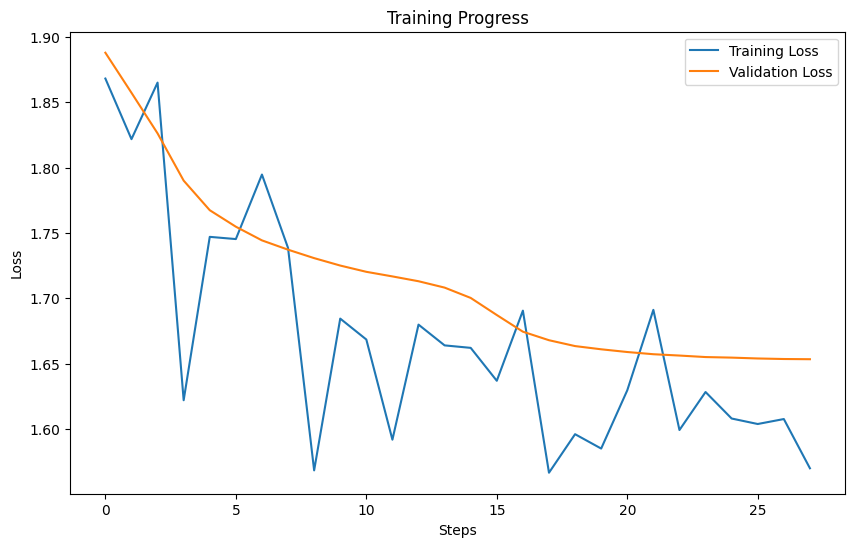

In [33]:
trainer = train_model(
    peft_model,
    tokenizer,
    split_dataset["train"],
    split_dataset["test"]
)
    
plot_loss(trainer)

In [34]:
prompt = "یک داسنان کوتاه در مورد دانشجوی دانشگاه تهران تعریف کن"
print("Base model response:")
print(generate_response(model, tokenizer, prompt))

Base model response:
یک داسنان کوتاه در مورد دانشجوی دانشگاه تهران تعریف کنه

داسنان کوتاه (توسعه‌ی عقل و ذهن) به عنوان یک فرایند بافتی و بوم‌شناختی، در حال حاضر یک پدیده اجتماعی-مادی است که با توجه به سطوح مختلف آن در جامعه، از سطوح آگاهی‌دار تا سطوح آگاهانه و به طور کلی، با توجه به این که در یک جامعه‌ای با تاریخ وCulture پررنگ، به‌عنوان یک میراث فرهنگی و عرفانی و نیز یک رویداد اجتماعی-مادی، به‌صورت متنوع و منحصر به فرد، به‌طور منظم و همگام با فرایندی متعارف در society بافت و تنش می‌پرورند. اگرچه به‌طور کلی، در طول تاریخ، داسنان کوتاه به‌صورت سنتی و بافتی، در جوامع مختلف و بر اساس سطوح مختلف آگاهی، و با
